# Vì sao cần chuẩn hóa? — Demo `MinMaxScaler`

Bám note **[[chuan-hoa-du-lieu]]** (slide L5 Phần 01 — TS. Cao Tiến Dũng).

**Vấn đề:** đặc trưng khác thang đo → cột số to **lấn át** khi tính khoảng cách / gradient.

| Scaler | Công thức | Kết quả | Bền outlier? |
|---|---|---|---|
| **MinMax** | (x − min)/(max − min) | về **[0, 1]** | Kém |
| **Standard** | (x − μ)/σ | mean 0, std 1 | Khá |
| **Robust** | (x − median)/IQR | quanh 0 | Tốt |

**Bị ảnh hưởng:** KNN · K-means · SVM · Gradient Descent · Regularization · PCA. **KHÔNG cần:** cây / RF / XGBoost.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

%matplotlib inline
plt.rcParams["axes.unicode_minus"] = False

## 1) Vấn đề: cột THU NHẬP (hàng chục nghìn) nuốt cột TUỔI (0–100)

In [2]:
rng = np.random.default_rng(0)
n = 200
tuoi = rng.integers(20, 70, n).astype(float)            # 20..70
thu_nhap = rng.normal(60000, 15000, n)                  # ~ hàng chục nghìn
X = np.column_stack([tuoi, thu_nhap])

# Khoảng cách Euclid giữa 2 người: bị thành phần nào chi phối?
a, b = X[0], X[1]
d_tuoi = (a[0] - b[0])**2
d_thu_nhap = (a[1] - b[1])**2
print(f"Chênh tuổi    : {a[0]-b[0]:+.0f}  → đóng góp vào d²: {d_tuoi:,.0f}")
print(f"Chênh thu nhập: {a[1]-b[1]:+.0f}  → đóng góp vào d²: {d_thu_nhap:,.0f}")
print(f"\n→ Thu nhập chiếm {d_thu_nhap/(d_tuoi+d_thu_nhap):.4%} khoảng cách → TUỔI bị bỏ qua hoàn toàn!")

Chênh tuổi    : +11  → đóng góp vào d²: 121
Chênh thu nhập: +905  → đóng góp vào d²: 818,134

→ Thu nhập chiếm 99.9852% khoảng cách → TUỔI bị bỏ qua hoàn toàn!


## 2) `MinMaxScaler` → ép cả hai về [0, 1] → công bằng

In [3]:
Xmm = MinMaxScaler().fit_transform(X)
print("Sau MinMax — min/max mỗi cột:")
print(f"  tuoi    : min={Xmm[:,0].min():.2f}  max={Xmm[:,0].max():.2f}")
print(f"  thu_nhap: min={Xmm[:,1].min():.2f}  max={Xmm[:,1].max():.2f}")

a, b = Xmm[0], Xmm[1]
d_tuoi = (a[0]-b[0])**2; d_thu_nhap = (a[1]-b[1])**2
print(f"\nSau chuẩn hóa, thu nhập chỉ còn chiếm {d_thu_nhap/(d_tuoi+d_thu_nhap):.1%} khoảng cách")
print("→ giờ TUỔI mới có tiếng nói. Đây là lý do KNN/SVM/K-means cần scale.")

Sau MinMax — min/max mỗi cột:
  tuoi    : min=0.00  max=1.00
  thu_nhap: min=0.00  max=1.00

Sau chuẩn hóa, thu nhập chỉ còn chiếm 0.2% khoảng cách
→ giờ TUỔI mới có tiếng nói. Đây là lý do KNN/SVM/K-means cần scale.


## 3) Nhìn bằng mắt: Trước vs Sau (giống slide)

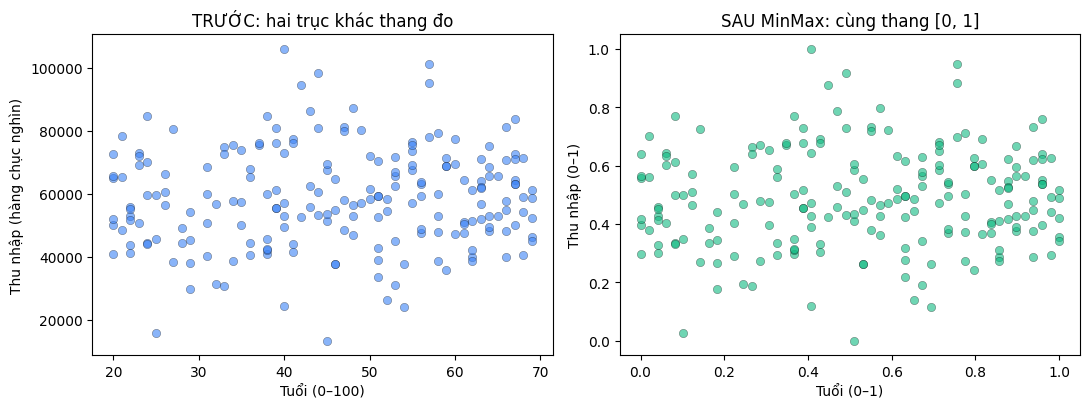

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(X[:,0], X[:,1], c="#3b82f6", alpha=0.6, edgecolor="k", linewidth=0.3)
ax[0].set_title("TRƯỚC: hai trục khác thang đo")
ax[0].set_xlabel("Tuổi (0–100)"); ax[0].set_ylabel("Thu nhập (hàng chục nghìn)")

ax[1].scatter(Xmm[:,0], Xmm[:,1], c="#10b981", alpha=0.6, edgecolor="k", linewidth=0.3)
ax[1].set_title("SAU MinMax: cùng thang [0, 1]")
ax[1].set_xlabel("Tuổi (0–1)"); ax[1].set_ylabel("Thu nhập (0–1)")
ax[1].set_xlim(-0.05, 1.05); ax[1].set_ylim(-0.05, 1.05)
fig.tight_layout(); plt.show()

## 4) ⚠️ Điểm yếu của MinMax: NHẠY OUTLIER

Thêm 1 người thu nhập cực lớn → `max` bị kéo lên → mọi giá trị khác **dồn về gần 0**.

In [5]:
X_out = X.copy()
X_out[0, 1] = 5_000_000          # 1 outlier thu nhập 5 triệu

mm = MinMaxScaler().fit_transform(X_out)[:, 1]
print("Cột thu nhập sau MinMax khi CÓ outlier:")
print(f"  outlier → {mm[0]:.2f} | phần còn lại dồn quanh {np.median(mm[1:]):.4f} (gần 0!)")
print("→ MinMax bị 1 outlier phá hỏng. Nhiều outlier → dùng RobustScaler (median/IQR).\n")

# So sánh 3 scaler trên cột có outlier
col = X_out[:, [1]]
for name, sc in [("MinMax", MinMaxScaler()), ("Standard", StandardScaler()), ("Robust", RobustScaler())]:
    z = sc.fit_transform(col).ravel()
    print(f"{name:>9}: phần thường nằm quanh {np.median(z[1:]):+.3f}, std(phần thường)={z[1:].std():.3f}")
print("→ Robust giữ phần dữ liệu thường ổn định nhất khi có outlier.")

Cột thu nhập sau MinMax khi CÓ outlier:
  outlier → 1.00 | phần còn lại dồn quanh 0.0089 (gần 0!)
→ MinMax bị 1 outlier phá hỏng. Nhiều outlier → dùng RobustScaler (median/IQR).

   MinMax: phần thường nằm quanh +0.009, std(phần thường)=0.003
 Standard: phần thường nằm quanh -0.073, std(phần thường)=0.045
   Robust: phần thường nằm quanh -0.006, std(phần thường)=0.739
→ Robust giữ phần dữ liệu thường ổn định nhất khi có outlier.


## ✅ Tóm tắt

- **Vì sao scale:** đặc trưng khác thang đo → cột to lấn át khoảng cách/gradient → KNN/SVM/GD/Regularization/PCA học sai.
- **MinMaxScaler** `(x−min)/(max−min)` → **[0,1]**: hợp khi cần biên rõ (ảnh, NN), phân phối không chuẩn. **Nhạy outlier**.
- **StandardScaler** (z-score) = mặc định; **RobustScaler** = khi nhiều outlier.
- ⚠️ **Leakage:** `fit` scaler **CHỈ trên train** → transform test. Gói `Pipeline`.
- Checklist đầy đủ: [[template-checklist]] Bước 3a.